# Pseudobulk tAge Analysis Tutorial

This tutorial demonstrates how to perform transcriptomic age (tAge) prediction on single-cell RNA-seq data using **coverage-based pseudobulk aggregation**.

Unlike traditional pseudobulk approaches that group cells by metadata categories and filter by cell count, tAge uses a **cumulative read coverage threshold** to construct pseudobulk samples. Cells are sequentially aggregated until the total read count reaches the specified threshold, ensuring each pseudobulk sample has sufficient sequencing depth for reliable age prediction.

We'll use the Tabula Muris Senis dataset (GSM4505404) as an example.

## 1. Setup and Package Loading

In [1]:
# Load the tAge package
devtools::document()
devtools::load_all()
library(tAge)

# Load other required packages
library(Seurat)
library(SeuratDisk)
library(ggplot2)

ℹ Updating tAge documentation
ℹ Loading tAge
ℹ Loading tAge
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat



## 2. Download and Load Data

First, let's download the Tabula Muris Senis dataset if not already available.

In [2]:
# Set data paths
h5ad_file <- "GSM4505404_tabula-muris-senis-droplet-official-raw-obj.h5ad"
metadata_file <- "GSM4505404_tabula-muris-senis-droplet-official-raw-obj-metadata.csv"

# Check if files exist
if (!file.exists(h5ad_file)) {
  cat("Please download the dataset from GEO:\n")
  cat("https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4505nnn/GSM4505404/suppl/GSM4505404_tabula-muris-senis-droplet-official-raw-obj.h5ad.gz\n")
  cat("https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4505nnn/GSM4505404/suppl/GSM4505404_tabula-muris-senis-droplet-official-raw-obj-metadata.csv.gz\n")
}

## 3. Load Data into R

For this tutorial, we'll load the data using anndata in Python and convert it, or use SeuratDisk.

In [3]:
# Alternative approach: Load using reticulate and anndata
library(reticulate)
use_python("./.venv/bin/python")

# Import anndata
ad <- import("anndata")
sc <- import("scanpy")

# Load h5ad file
adata <- ad$read_h5ad(h5ad_file)

cat("Loaded AnnData object:\n")
cat("  - Cells:", adata$n_obs, "\n")
cat("  - Genes:", adata$n_vars, "\n")

Loaded AnnData object:
  - Cells: 245389 
  - Genes: 20138 


## 4. Convert to Seurat Object

We'll convert the AnnData object to a Seurat object for downstream analysis.

In [4]:
# Extract counts and metadata
counts <- Matrix::t(adata$X)
rownames(counts) <- adata$var_names$to_list()
colnames(counts) <- adata$obs_names$to_list()

# Extract metadata
metadata <- as.data.frame(adata$obs)

# Create Seurat object
seurat_obj <- CreateSeuratObject(
  counts = counts,
  meta.data = metadata,
  project = "TabMurisSenis"
)

cat("Created Seurat object:\n")
print(seurat_obj)

Warning message:
“Data is of class dgRMatrix. Coercing to dgCMatrix.”


Created Seurat object:
An object of class Seurat 
20138 features across 245389 samples within 1 assay 
Active assay: RNA (20138 features, 0 variable features)
 1 layer present: counts


## 5. Explore the Data

In [5]:
# Check available metadata columns
cat("Available metadata columns:\n")
print(colnames(seurat_obj@meta.data))

# Summary statistics
cat("\nSample distribution by age:\n")
print(table(seurat_obj$age))

cat("\nSample distribution by tissue:\n")
print(table(seurat_obj$tissue))

cat("\nSample distribution by sex:\n")
print(table(seurat_obj$sex))

Available metadata columns:
 [1] "orig.ident"             "nCount_RNA"             "nFeature_RNA"          
 [4] "age"                    "cell"                   "cell_ontology_class"   
 [7] "cell_ontology_id"       "free_annotation"        "method"                
[10] "mouse.id"               "n_genes"                "sex"                   
[13] "subtissue"              "tissue"                 "tissue_free_annotation"

Sample distribution by age:

   1m    3m   18m   21m   24m   30m 
25980 45602 44645 35828 37660 55674 

Sample distribution by tissue:

        Bladder             Fat Heart_and_Aorta          Kidney Large_Intestine 
           8945            6777            8613           21647            1887 
    Limb_Muscle           Liver            Lung   Mammary_Gland          Marrow 
          28867            7294           24540           12295           40220 
       Pancreas            Skin          Spleen          Thymus          Tongue 
           6201            445

## 6. Subset Data for Demo

For demonstration purposes, let's focus on a subset of tissues and filter the data.

In [6]:
# Select specific tissues for analysis
selected_tissues <- c("Tongue", "Kidney", "Liver", "Heart")

seurat_subset <- subset(seurat_obj, subset = tissue %in% selected_tissues)

cat("Subset Seurat object:\n")
print(seurat_subset)

# Check cell counts per mouse.id and tissue
cell_counts <- table(seurat_subset$mouse.id, seurat_subset$tissue)
cat("\nCells per sample and tissue:\n")
print(cell_counts[rowSums(cell_counts) > 0, ])

Subset Seurat object:
An object of class Seurat 
20138 features across 49621 samples within 1 assay 
Active assay: RNA (20138 features, 0 variable features)
 1 layer present: counts

Cells per sample and tissue:
         
          Bladder  Fat Heart_and_Aorta Kidney Large_Intestine Limb_Muscle Liver
  1-M-62        0    0               0   1325               0           0   471
  1-M-63        0    0               0   1163               0           0  2320
  3-F-56        0    0               0      0               0           0   387
  3-F-57        0    0               0   1118               0           0   179
  3-M-8         0    0               0    524               0           0     0
  3-M-8/9       0    0               0      0               0           0   460
  3-M-9         0    0               0    688               0           0     0
  18-F-50       0    0               0    825               0           0     0
  18-F-51       0    0               0   1197             

## 7. Examine Per-Cell Library Sizes

Before pseudobulk aggregation, let's look at the distribution of reads per cell. This helps choose an appropriate coverage threshold.

Per-cell library size summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2500    4896    9749   12955   16651  169540 

Total reads across all cells: 642,853,059 
Total cells: 49621 


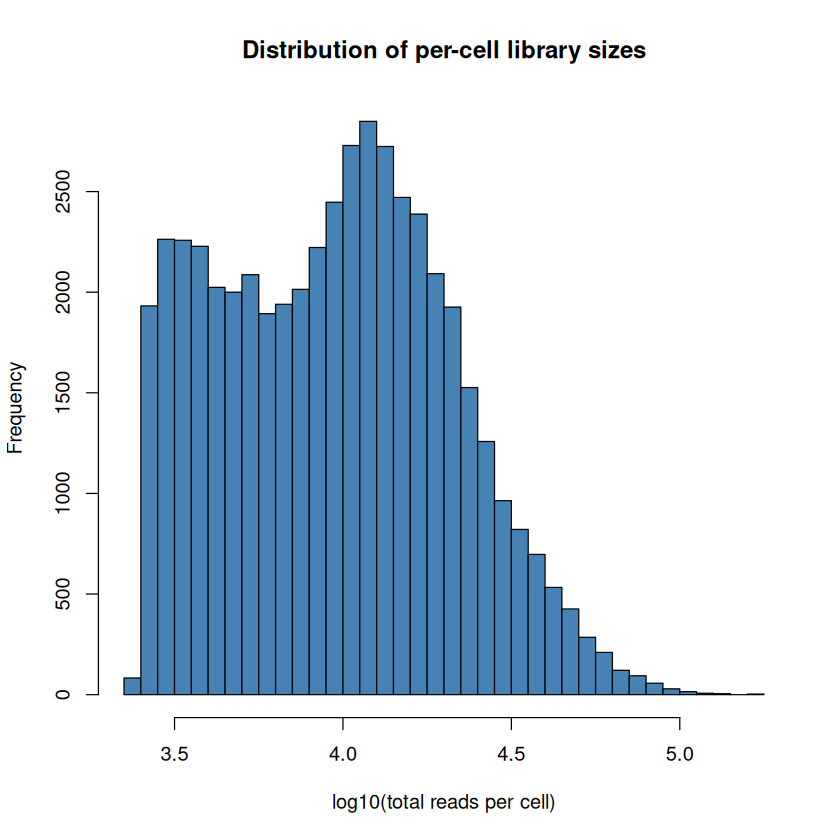

In [7]:
# Calculate per-cell library sizes
lib_sizes <- Matrix::colSums(Seurat::GetAssayData(seurat_subset, layer = "counts"))

cat("Per-cell library size summary:\n")
print(summary(lib_sizes))
cat("\nTotal reads across all cells:", format(sum(lib_sizes), big.mark = ","), "\n")
cat("Total cells:", length(lib_sizes), "\n")

# Histogram
hist(log10(lib_sizes), breaks = 50, main = "Distribution of per-cell library sizes",
     xlab = "log10(total reads per cell)", col = "steelblue")

## 8. Coverage-Based Pseudobulk Aggregation

The core idea: instead of grouping cells by metadata and filtering by cell count, we **sequentially accumulate cells until a cumulative read coverage threshold is reached**. This ensures each pseudobulk sample has sufficient sequencing depth.

### 8a. Simple aggregation (all cells together)

Aggregate all cells into pseudobulk samples with at least 1 million reads each.

Aggregating pseudobulk samples by coverage...
  - Total cells: 49621 
  - Total genes: 20138 
  - Coverage threshold: 3e+05 reads
  - Pseudobulk samples created: 2143 
  - Samples meeting threshold: 1067 
  - Remainder sample (below threshold): 1 ( 253,861  reads,  35  cells)
  - Coverage per sample (median): 299,965 reads
  - Cells per sample (median): 17 
✓ ExpressionSet created successfully
  - Number of genes: 20138 
  - Number of samples: 2143 
✓ Pseudobulk aggregation completed

Pseudobulk ExpressionSet:
ExpressionSet (storageMode: lockedEnvironment)
assayData: 20138 features, 2143 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: pseudobulk_1 pseudobulk_2 ... pseudobulk_2143 (2143
    total)
  varLabels: sample_id cumulative_coverage n_cells
  varMetadata: labelDescription
featureData: none
experimentData: use 'experimentData(object)'
Annotation:  

Pseudobulk sample metadata:
                      sample_id cumulative_coverage n_cells
pseudobulk_1    

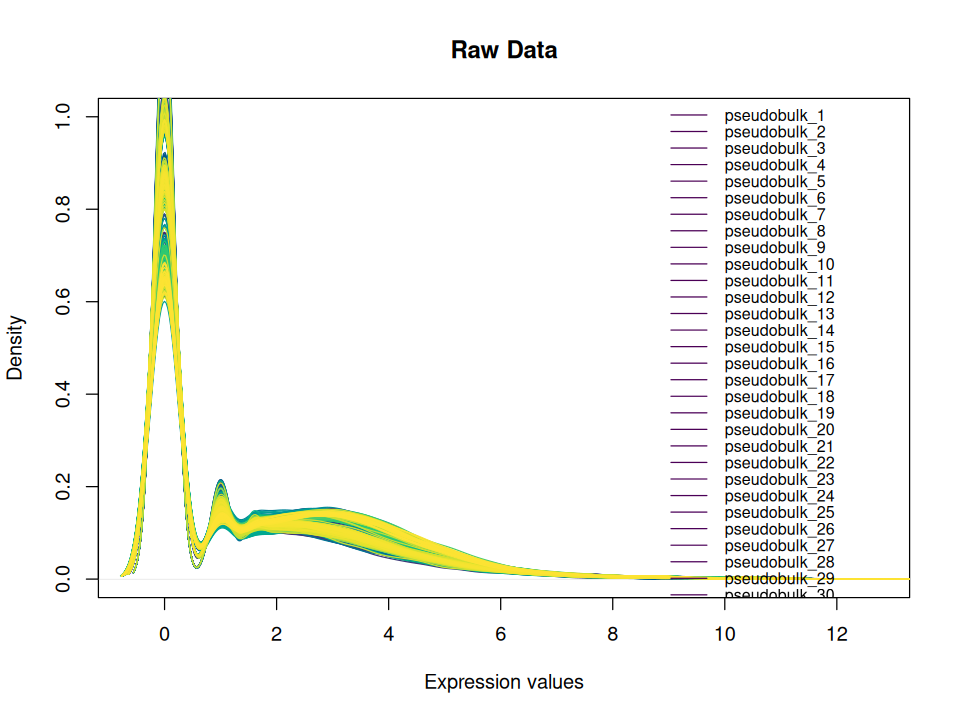

In [8]:
# Coverage-based aggregation: each pseudobulk sample gets >= 1M reads
eset_simple <- aggregate_pseudobulk(
  seurat_obj = seurat_subset,
  coverage_threshold = 300000,
  verbose = TRUE
)

cat("\nPseudobulk ExpressionSet:\n")
print(eset_simple)

# Inspect metadata
cat("\nPseudobulk sample metadata:\n")
print(Biobase::pData(eset_simple))

### 8b. Stratified aggregation by metadata columns

Aggregate within each unique combination of mouse ID and tissue. This preserves biological structure — each pseudobulk sample belongs to one mouse and one tissue.

Aggregating pseudobulk by obs columns: age, mouse.id, tissue 
  - Unique combinations: 37 
✓ ExpressionSet created successfully
  - Number of genes: 20138 
  - Number of samples: 656 
✓ Combined pseudobulk aggregation completed
  - Total pseudobulk samples: 656 
  - Total genes: 20138 

Stratified pseudobulk ExpressionSet:
ExpressionSet (storageMode: lockedEnvironment)
assayData: 20138 features, 656 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: pseudobulk_1 pseudobulk_2 ... pseudobulk_656 (656 total)
  varLabels: sample_id cumulative_coverage ... tissue (6 total)
  varMetadata: labelDescription
featureData: none
experimentData: use 'experimentData(object)'
Annotation:  

Pseudobulk sample metadata:
               cumulative_coverage n_cells age mouse.id tissue
pseudobulk_1               1007555      44 24m  24-M-60 Tongue
pseudobulk_2               1012523      46 24m  24-M-60 Tongue
pseudobulk_3               1003629      48 24m  24-M-60 Tongue
pseudobul

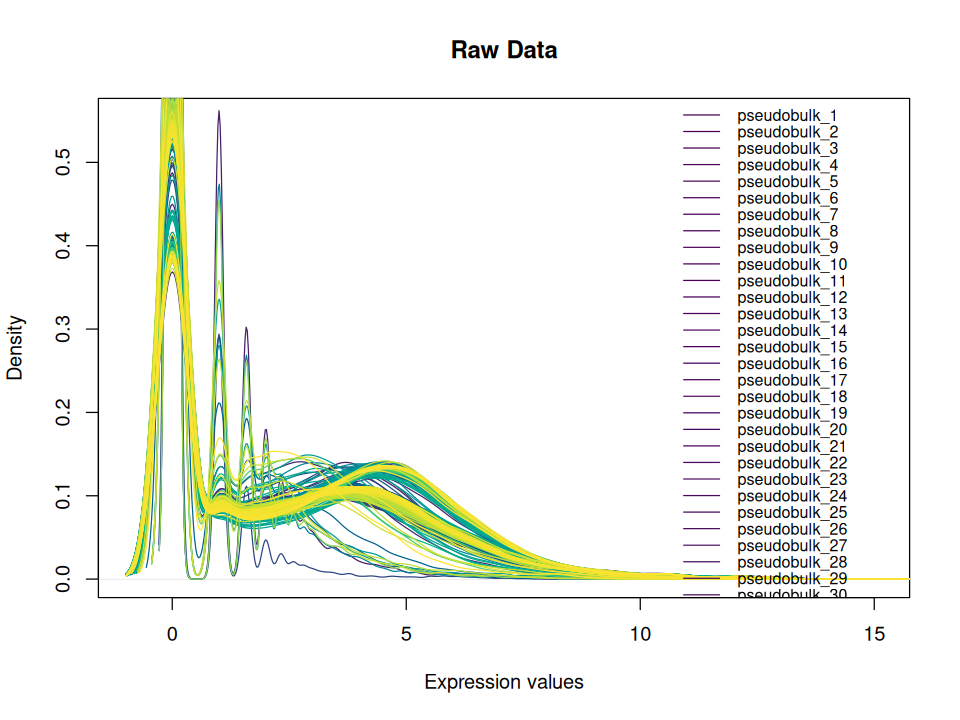

In [9]:
# Stratified aggregation: split by age, mouse.id and tissue, then aggregate by coverage
eset_stratified <- aggregate_on_obs_columns(
  seurat_obj = seurat_subset,
  obs_column_names = c("age", "mouse.id", "tissue"),
  coverage_threshold = 1e6,
  verbose = TRUE
)

cat("\nStratified pseudobulk ExpressionSet:\n")
print(eset_stratified)

# Inspect metadata — each sample now has age, mouse.id and tissue labels
cat("\nPseudobulk sample metadata:\n")
pdata <- Biobase::pData(eset_stratified)
print(pdata[, c("cumulative_coverage", "n_cells", "age", "mouse.id", "tissue")])

Removing outliers by group: tissue 
  - Groups: 3 

  [ Tongue ]  401  samples
    - Mahalanobis outliers: 10 
    - Additional IQR outliers: 4 
    - Removed: 14 outliers
  [ Kidney ]  170  samples
    - Mahalanobis outliers: 8 
    - Additional IQR outliers: 46 


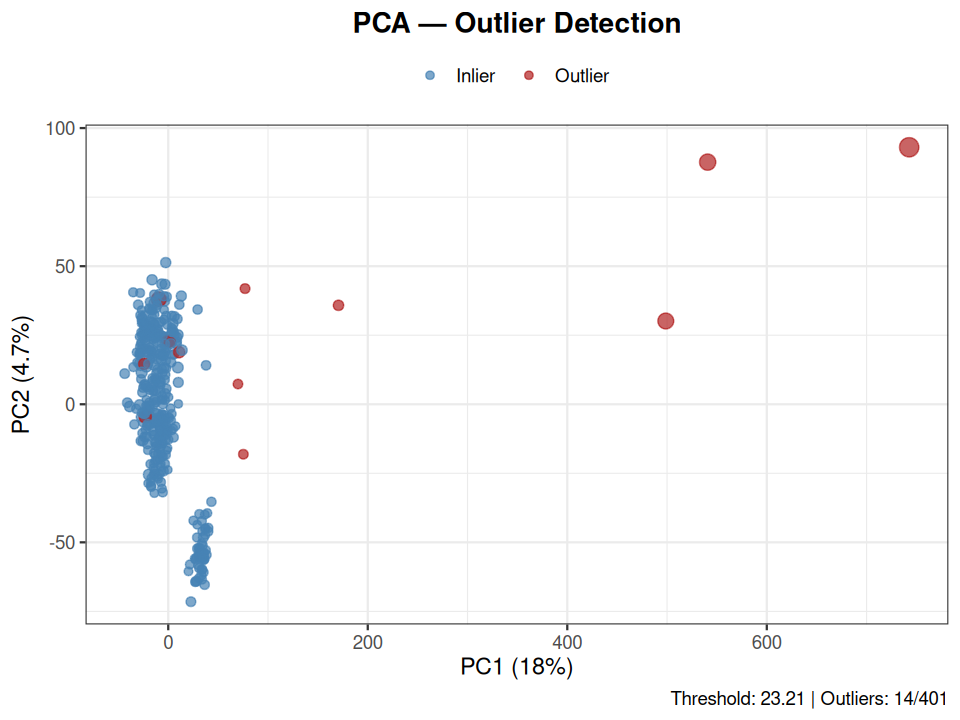

    - Removed: 54 outliers
  [ Liver ]  85  samples
    - Mahalanobis outliers: 9 


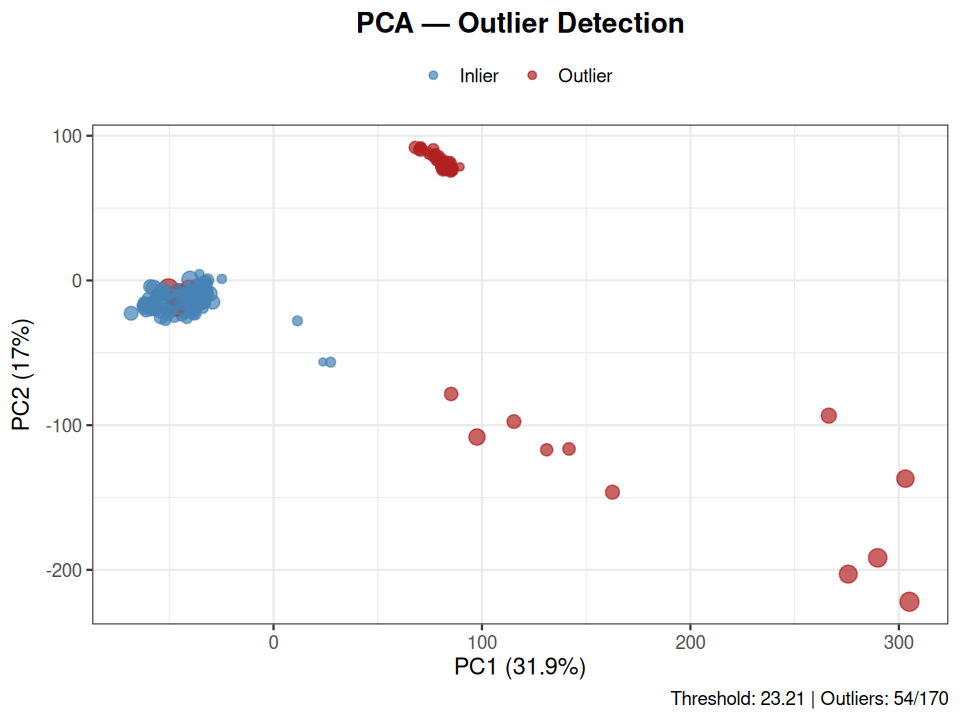

    - Removed: 9 outliers

✓ Total: removed 77 of 656 samples ( 11.7 %)
  - Samples retained: 579 


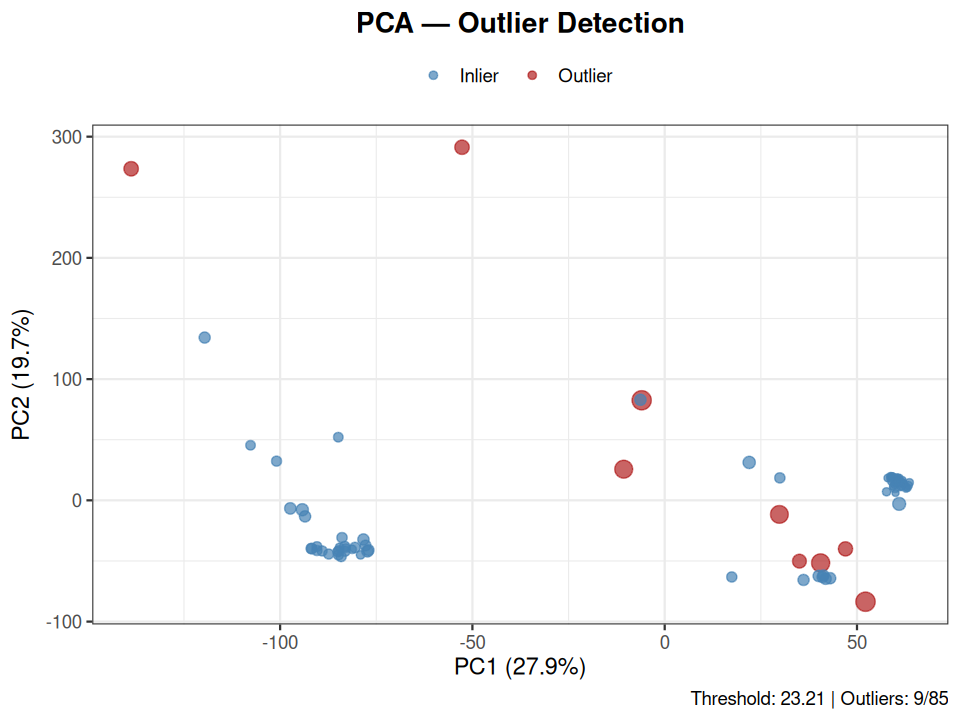

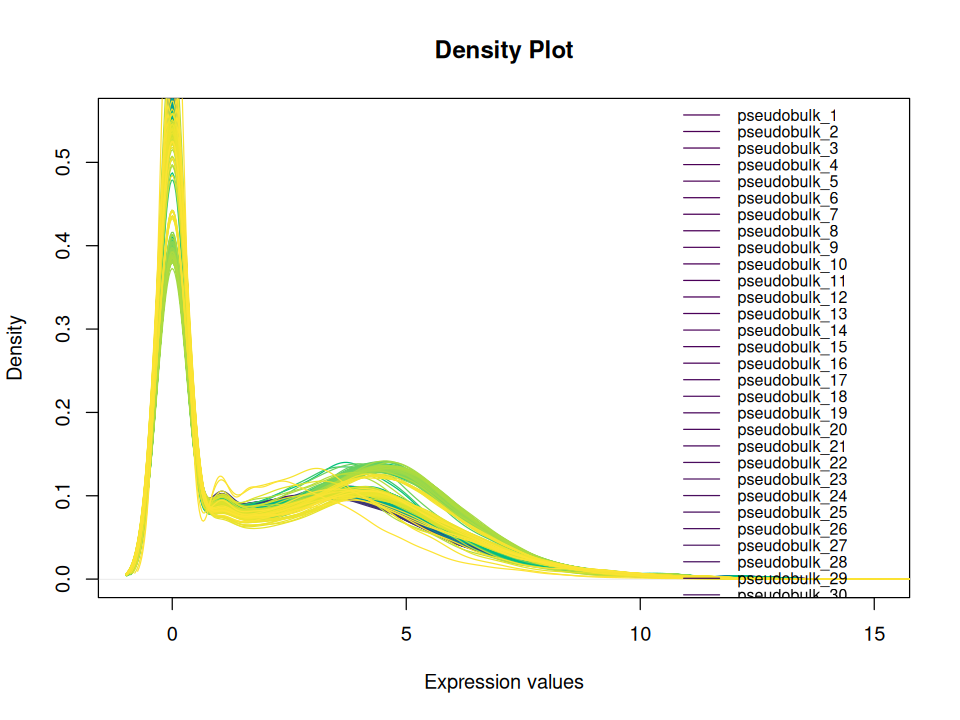

In [10]:
eset_stratified_PCA_filtered <- remove_outliers(eset_stratified, split_by = "tissue")
plot_eset_density(eset_stratified_PCA_filtered)

## 9. Preprocessing and tAge Prediction

Now we'll apply the standard tAge preprocessing and prediction pipeline to the stratified pseudobulk data.

Aggregating pseudobulk by obs columns: age, mouse.id, tissue 
  - Unique combinations: 37 
✓ ExpressionSet created successfully
  - Number of genes: 20138 
  - Number of samples: 82 
✓ Combined pseudobulk aggregation completed
  - Total pseudobulk samples: 82 
  - Total genes: 20138 


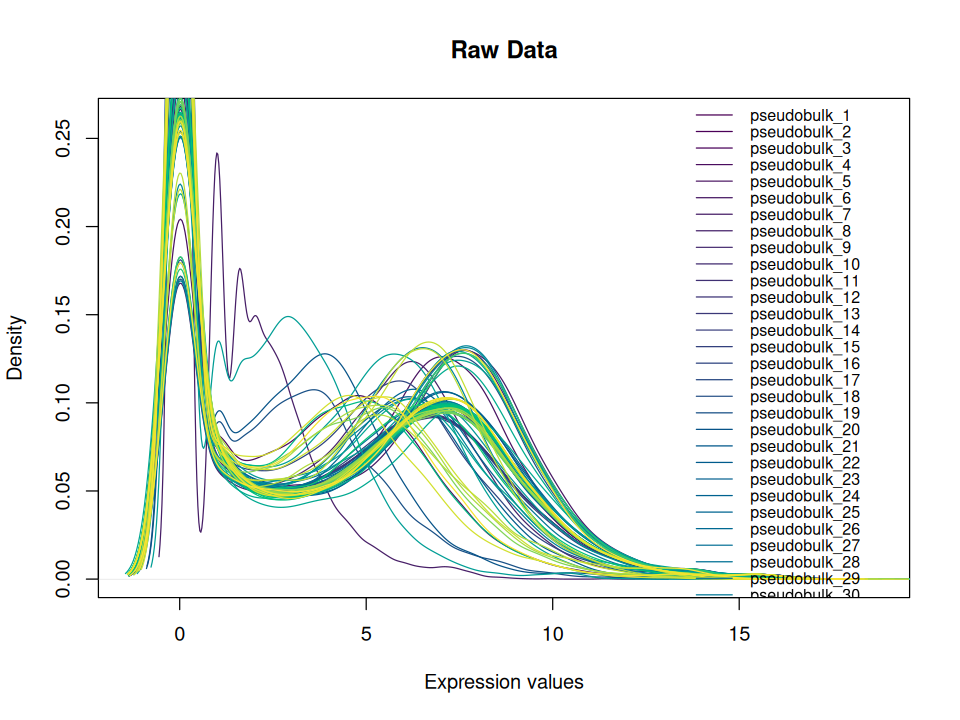

In [23]:
eset_tissue <- aggregate_on_obs_columns(
  seurat_obj = seurat_subset,
  obs_column_names = c("age", "mouse.id", "tissue"),
  coverage_threshold = 1e7,
  verbose = TRUE
)

Removing outliers by group: tissue 
  - Groups: 3 

  [ Tongue ]  45  samples
    - Mahalanobis outliers: 2 
    - Additional IQR outliers: 5 
    - Removed: 7 outliers
  [ Kidney ]  21  samples
    - Mahalanobis outliers: 0 
    - Additional IQR outliers: 6 


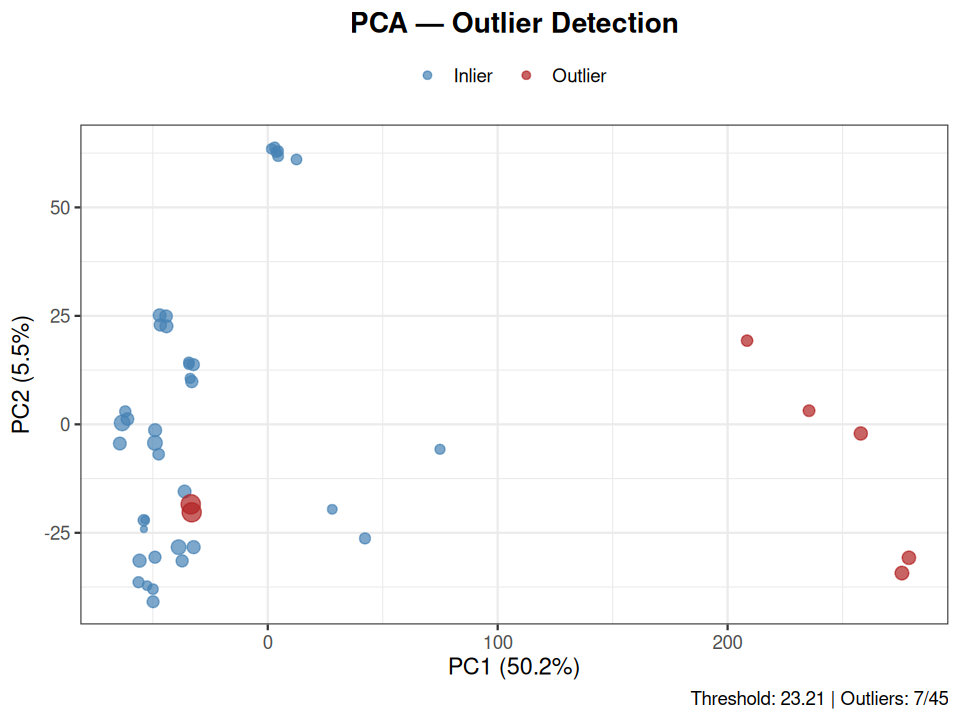

    - Removed: 6 outliers
  [ Liver ]  16  samples
    Clamping PCA components from 10 to 7 


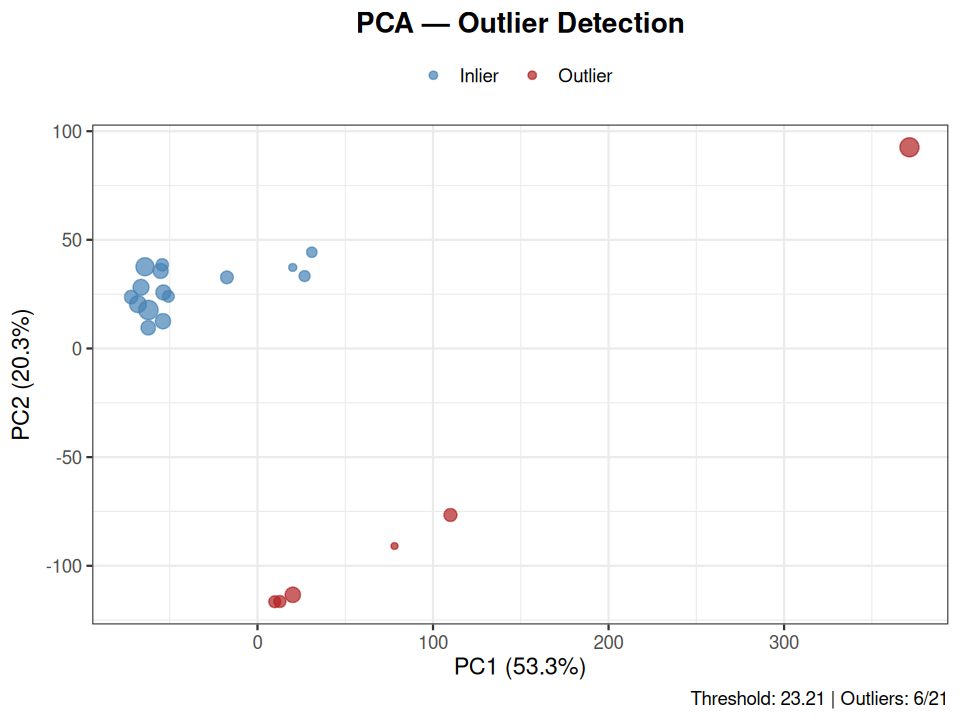

    - No outliers

✓ Total: removed 13 of 82 samples ( 15.9 %)
  - Samples retained: 69 


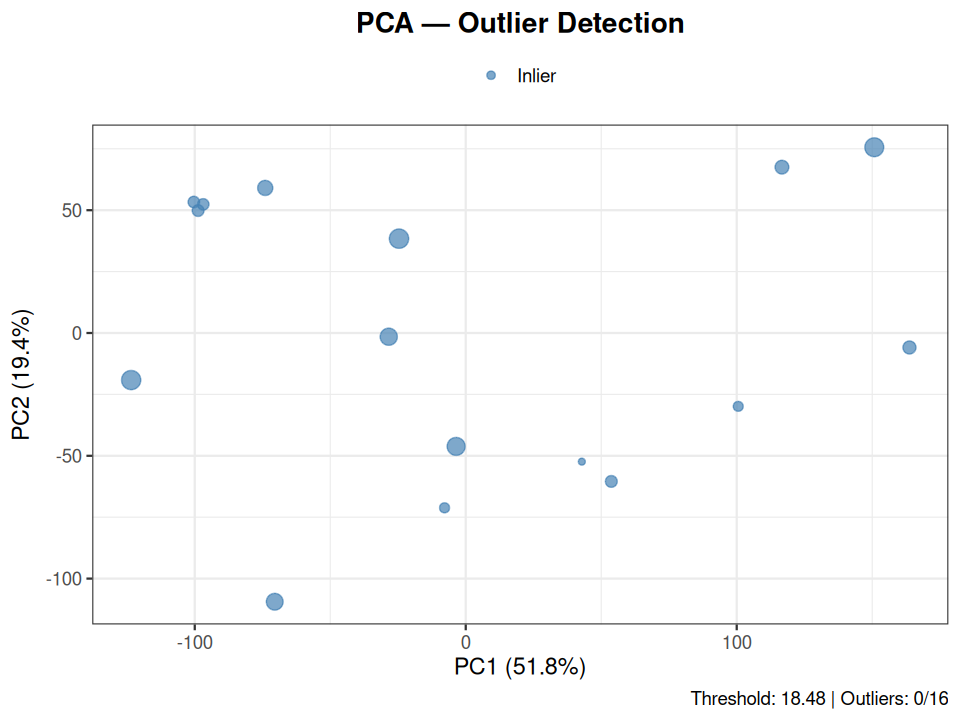

In [24]:
eset_clean <- remove_outliers(eset_tissue, split_by = "tissue")

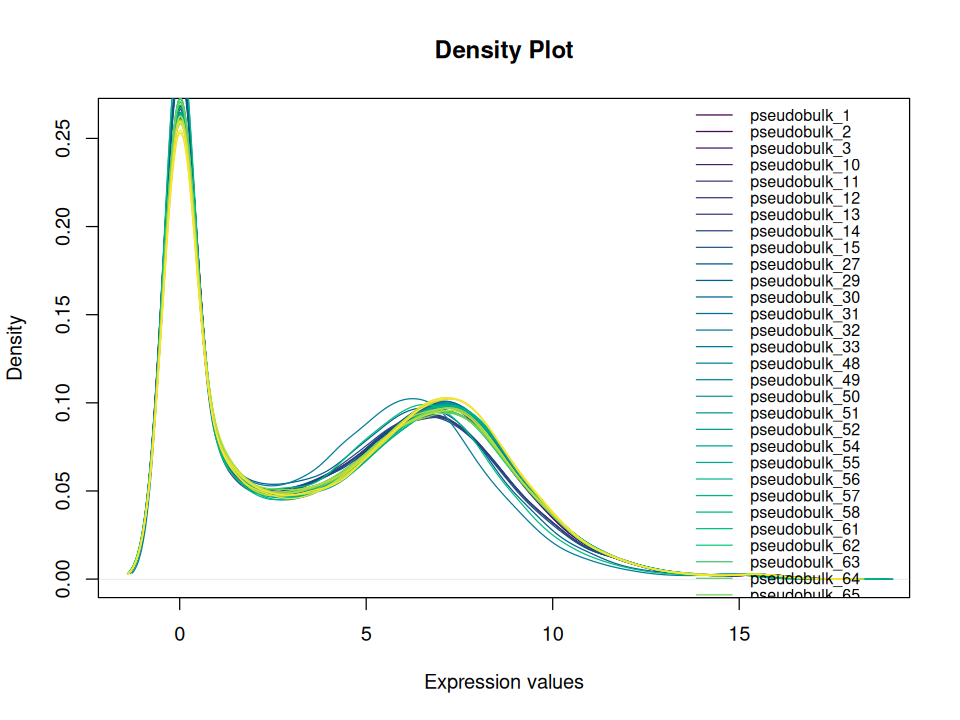

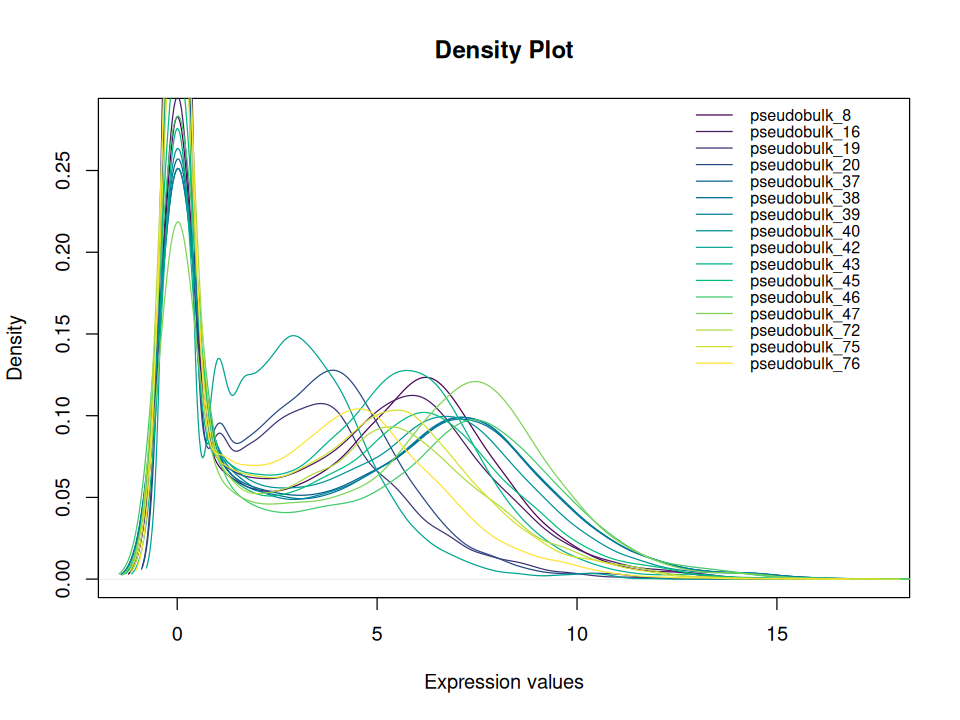

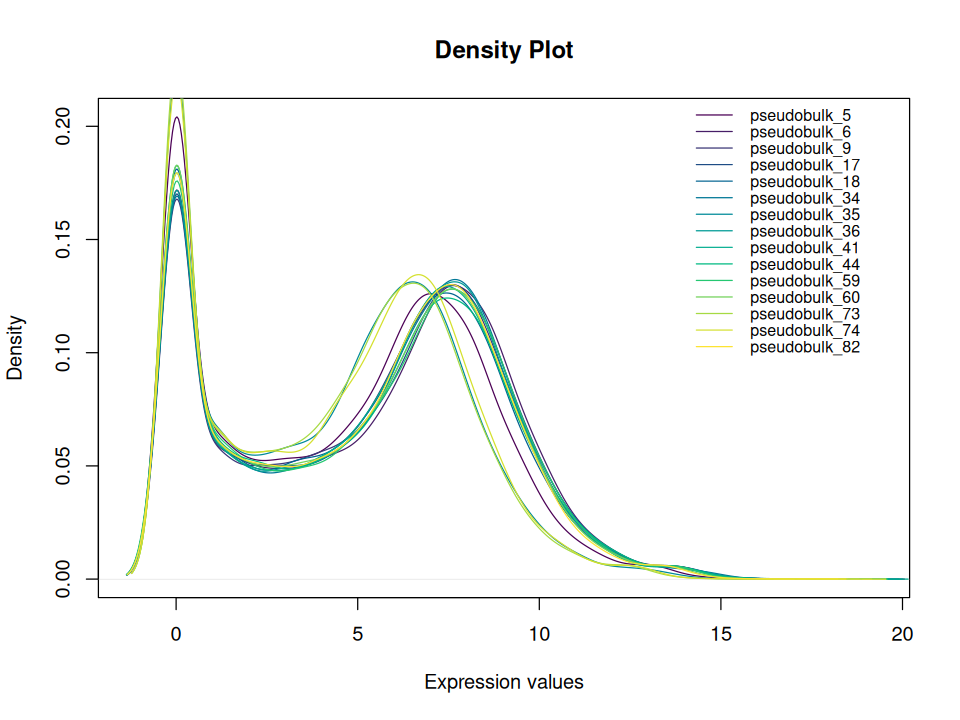

In [25]:
pdata <- Biobase::pData(eset_clean)
mask <- pdata$tissue == "Tongue"
eset_test <- eset_clean[, mask]
plot_eset_density(eset_test)

pdata <- Biobase::pData(eset_clean)
mask <- pdata$tissue == "Liver"
eset_test <- eset_clean[, mask]
plot_eset_density(eset_test)

pdata <- Biobase::pData(eset_clean)
mask <- pdata$tissue == "Kidney"
eset_test <- eset_clean[, mask]
plot_eset_density(eset_test)

Running tAge by tissue 
  - Groups: 3 
  - Groups: Tongue, Kidney, Liver 

===  Tongue  ( 38  samples) ===
✓ Gene filtering completed
  - Number of genes before filtering: 20138 
  - Number of genes after filtering: 11445 
  - Percentage of genes retained: 56.8 %
✓ RLE normalization completed
✓ Log transformation completed


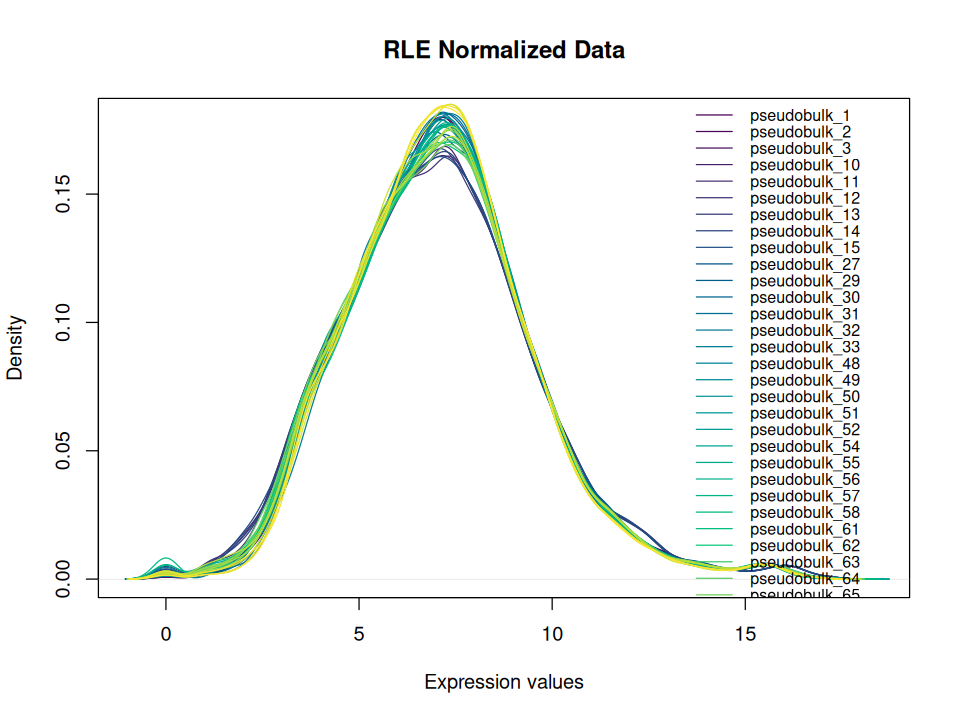

✓ Scaling completed


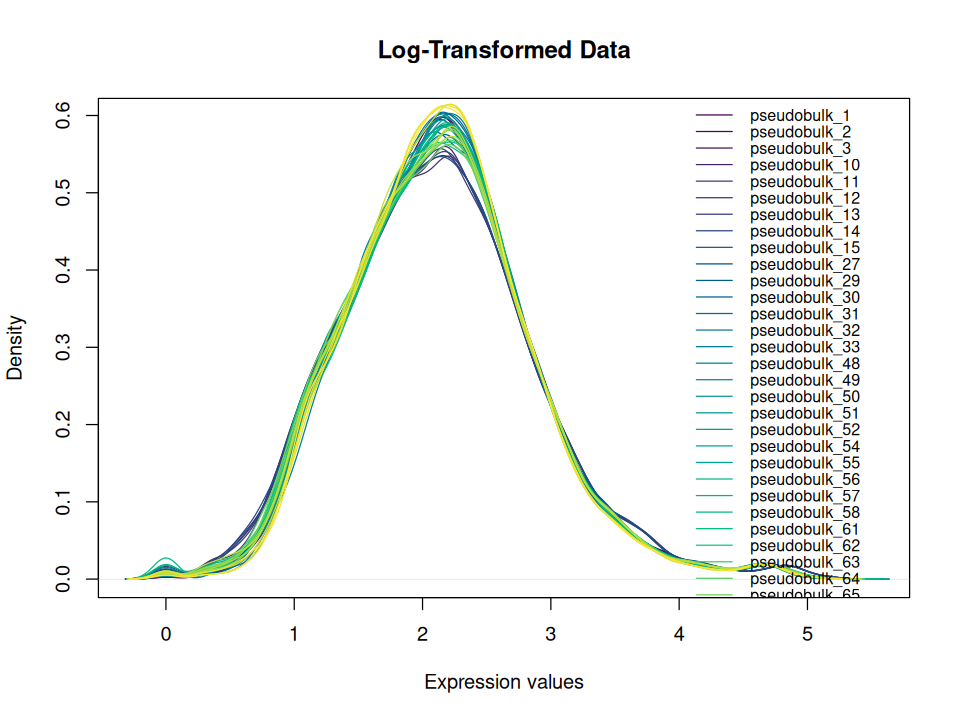

✓ YuGene normalization completed


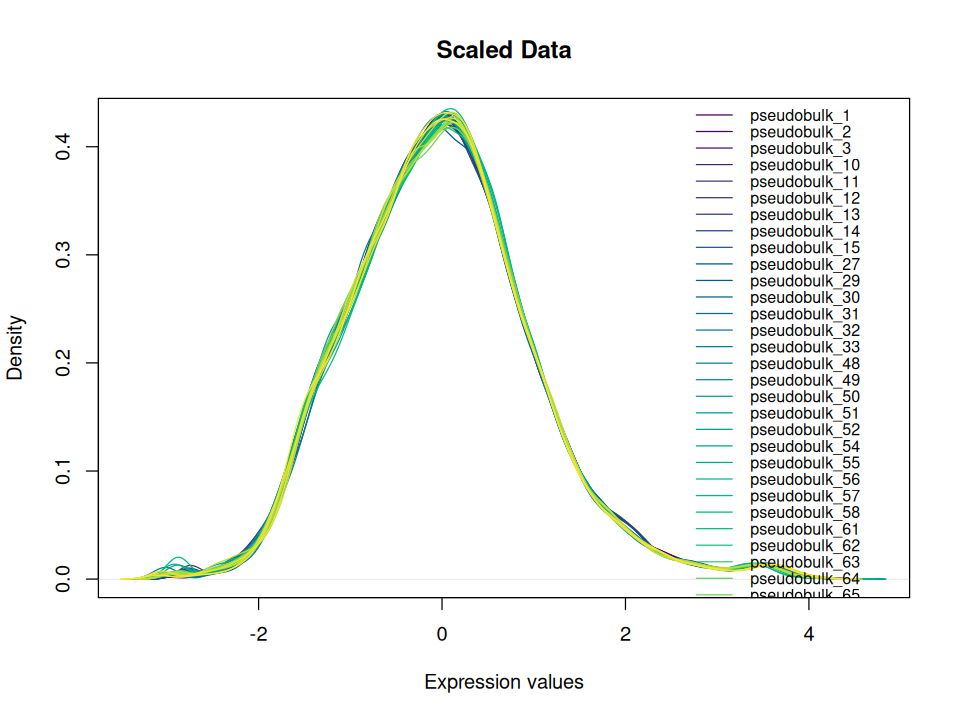

✓ Control samples found for label '1m'. Using control group median for subtraction.


Warning message in doTryCatch(return(expr), name, parentenv, handler):
“NaNs produced”


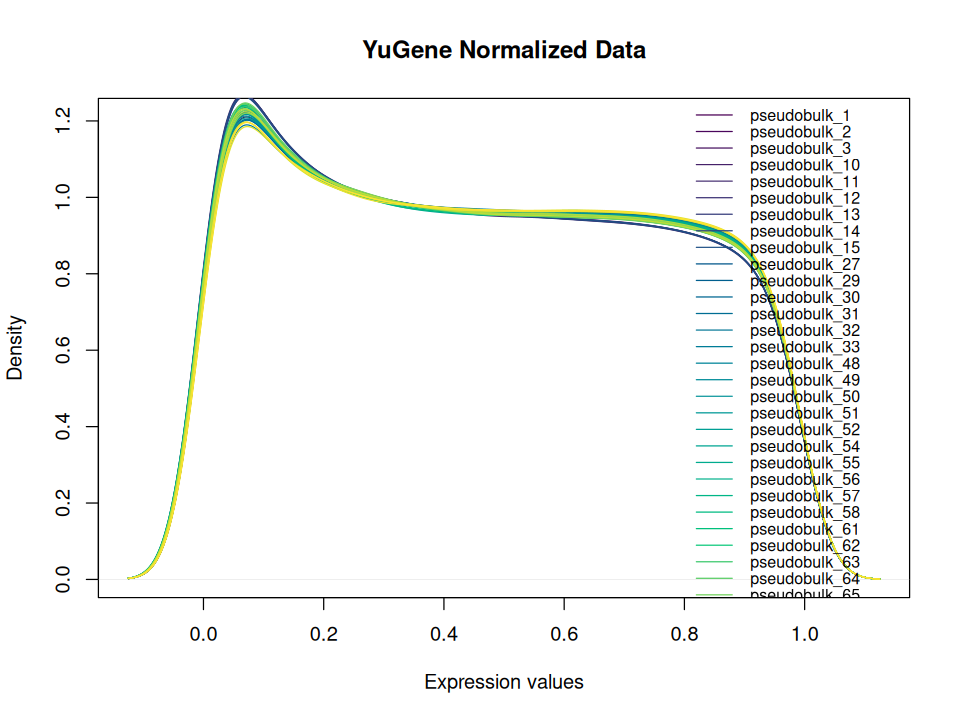

✓ Control samples found for label '1m'. Using control group median for subtraction.


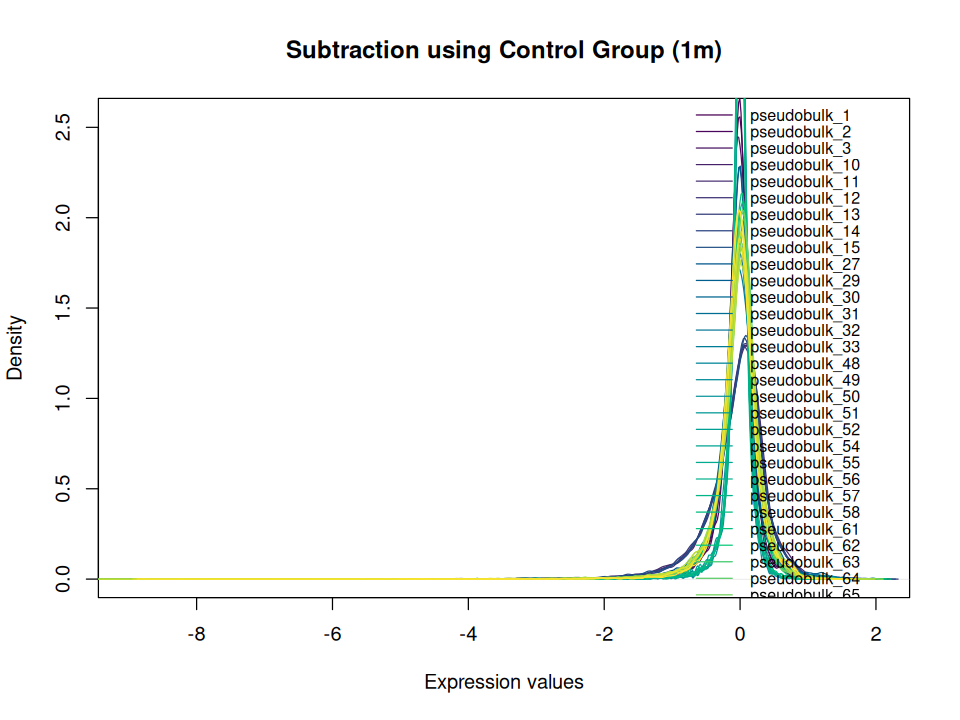


===  Kidney  ( 15  samples) ===
✓ Gene filtering completed
  - Number of genes before filtering: 20138 
  - Number of genes after filtering: 13955 
  - Percentage of genes retained: 69.3 %
✓ RLE normalization completed


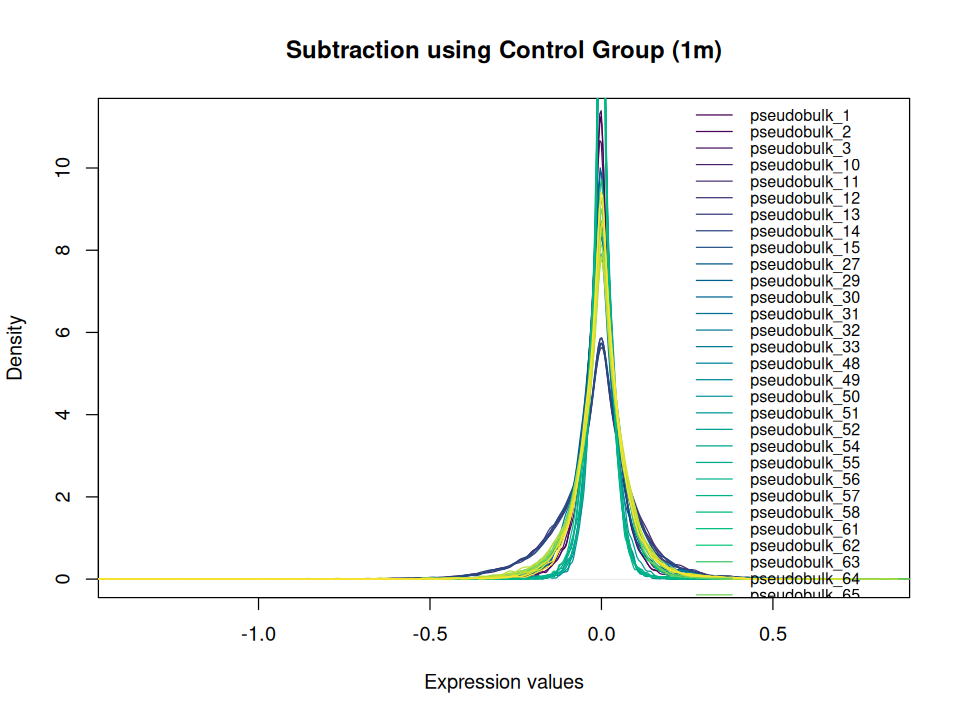

✓ Log transformation completed


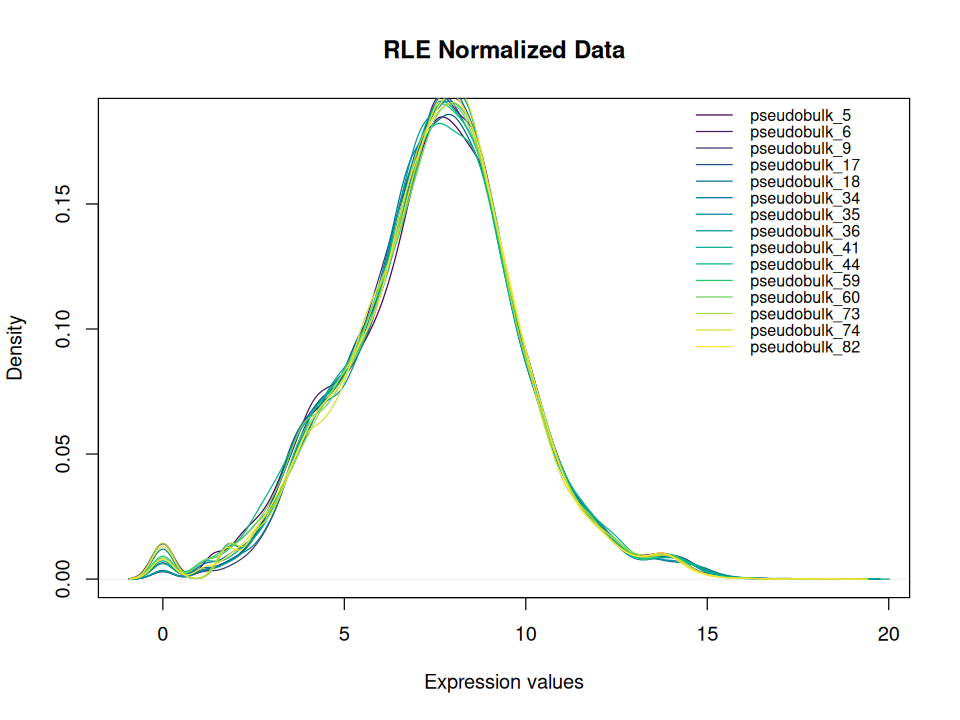

✓ Scaling completed


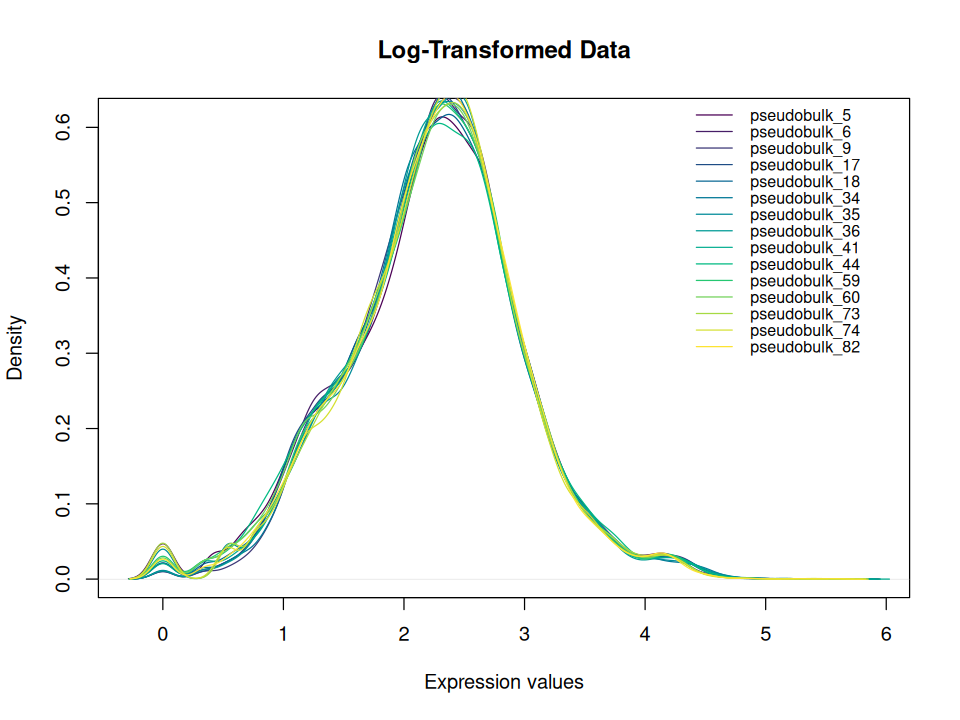

✓ YuGene normalization completed


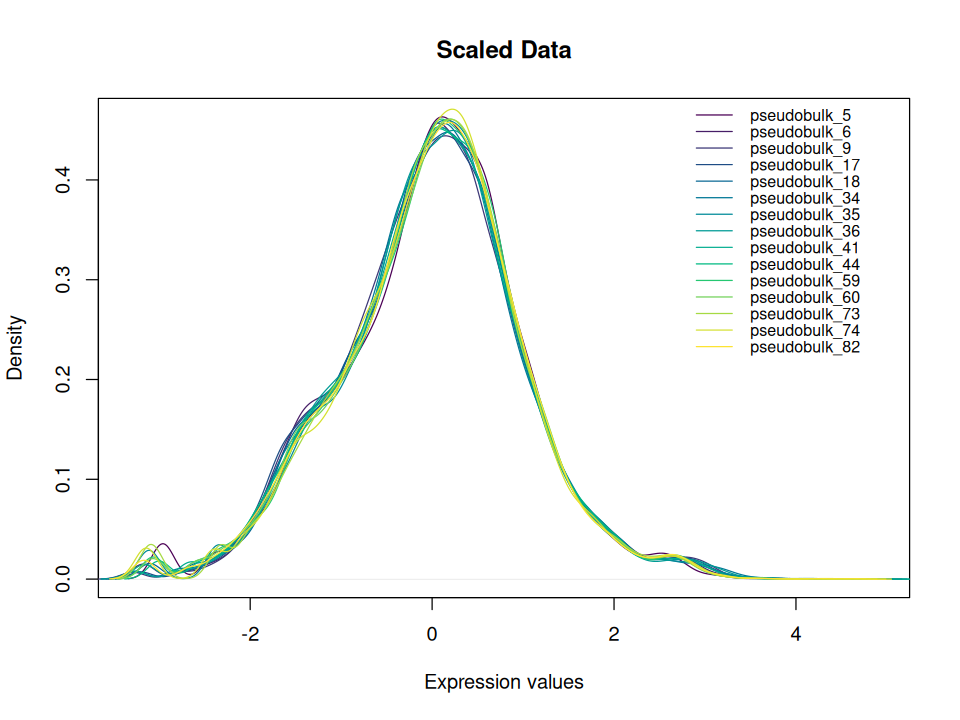

✓ Control samples found for label '1m'. Using control group median for subtraction.


Warning message in doTryCatch(return(expr), name, parentenv, handler):
“NaNs produced”


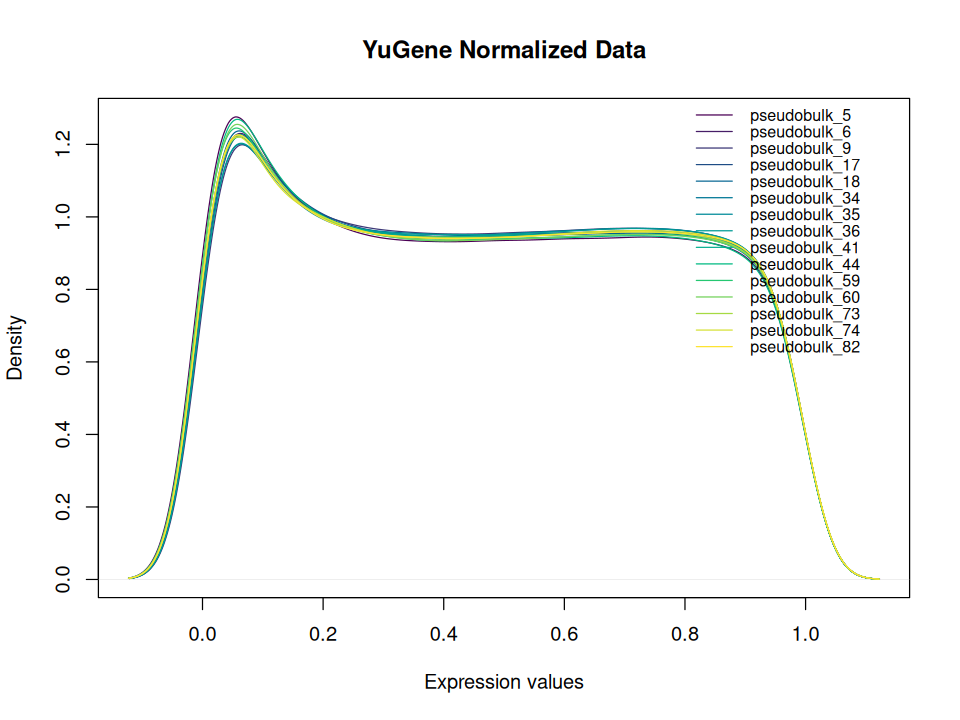

✓ Control samples found for label '1m'. Using control group median for subtraction.


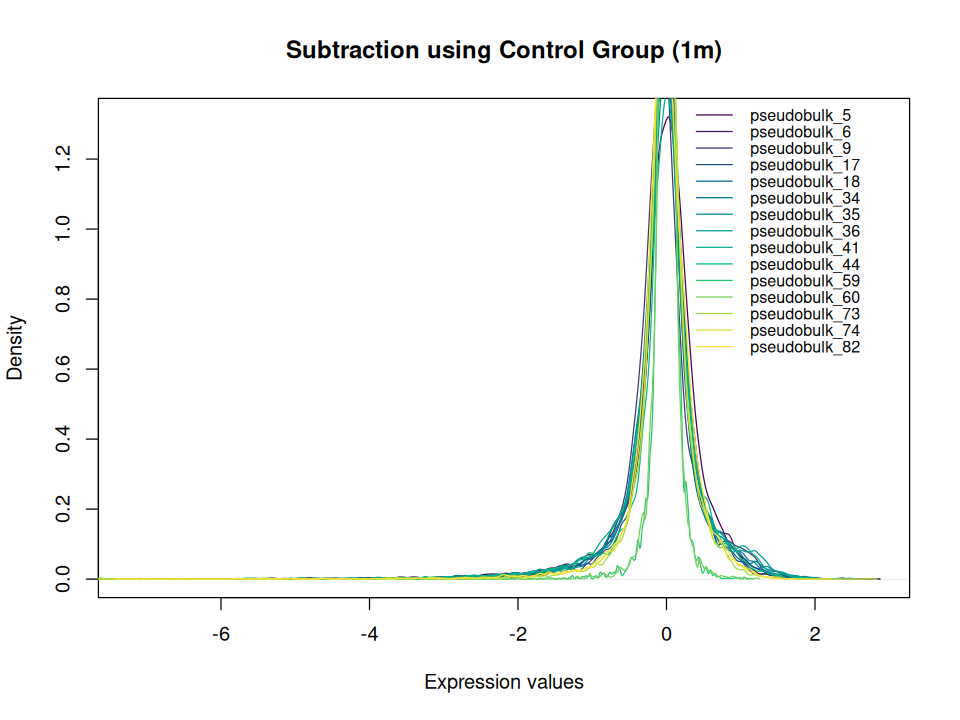


===  Liver  ( 16  samples) ===
✓ Gene filtering completed
  - Number of genes before filtering: 20138 
  - Number of genes after filtering: 12132 
  - Percentage of genes retained: 60.2 %
✓ RLE normalization completed


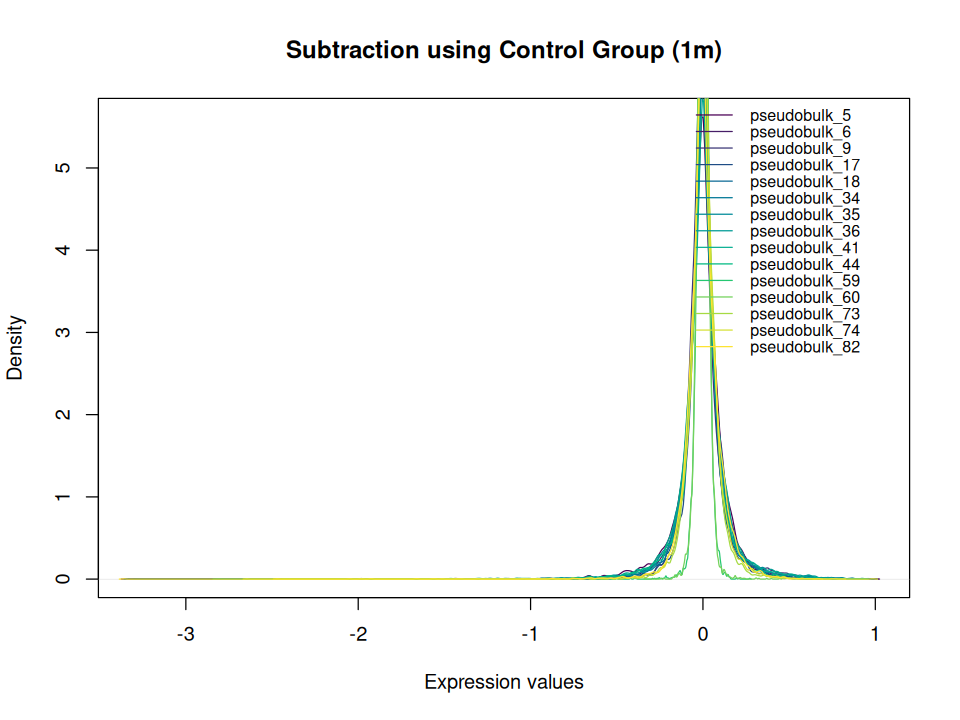

✓ Log transformation completed


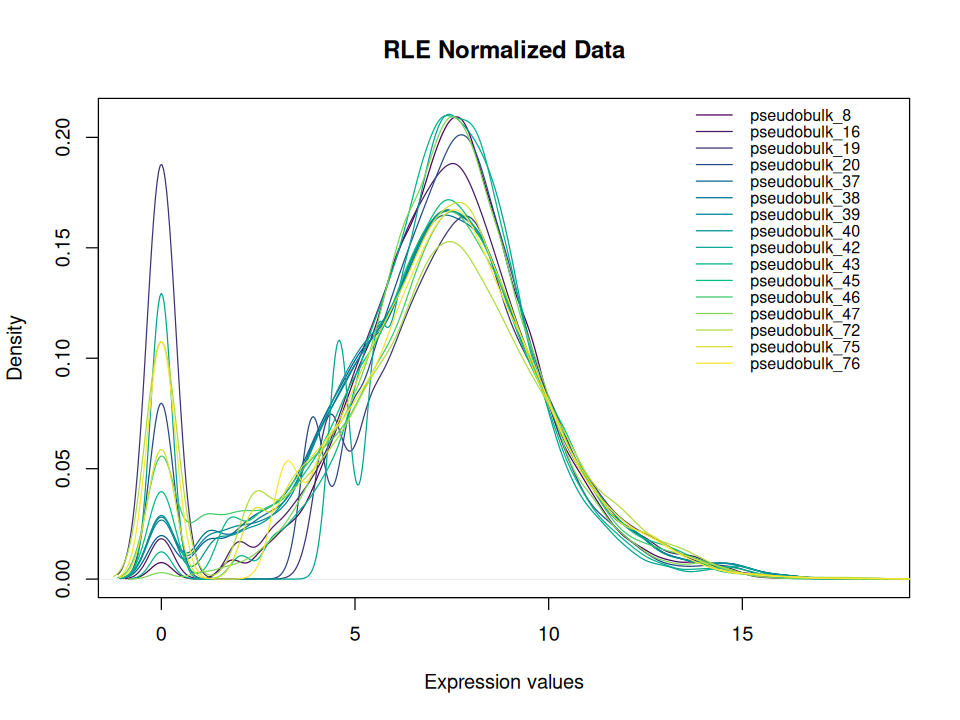

✓ Scaling completed


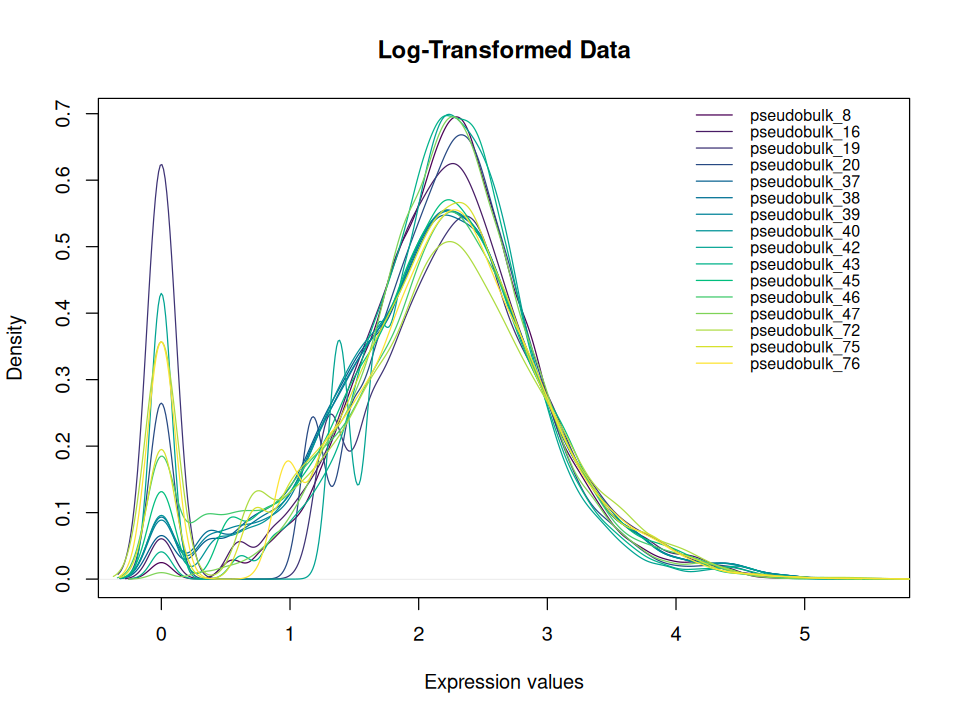

✓ YuGene normalization completed


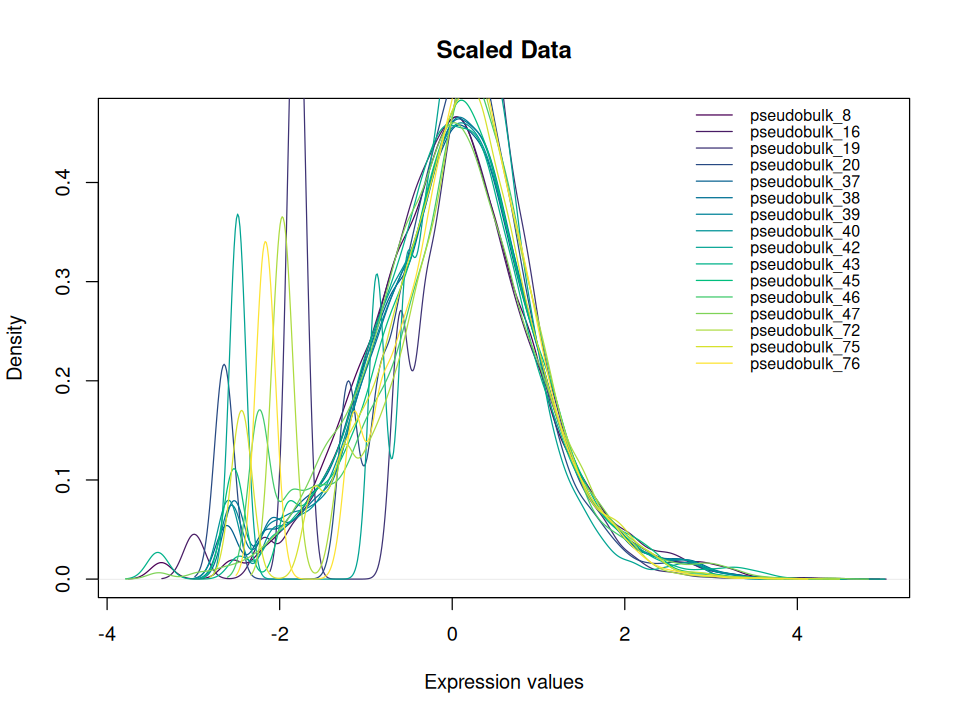

✓ Control samples found for label '1m'. Using control group median for subtraction.


Warning message in doTryCatch(return(expr), name, parentenv, handler):
“NaNs produced”


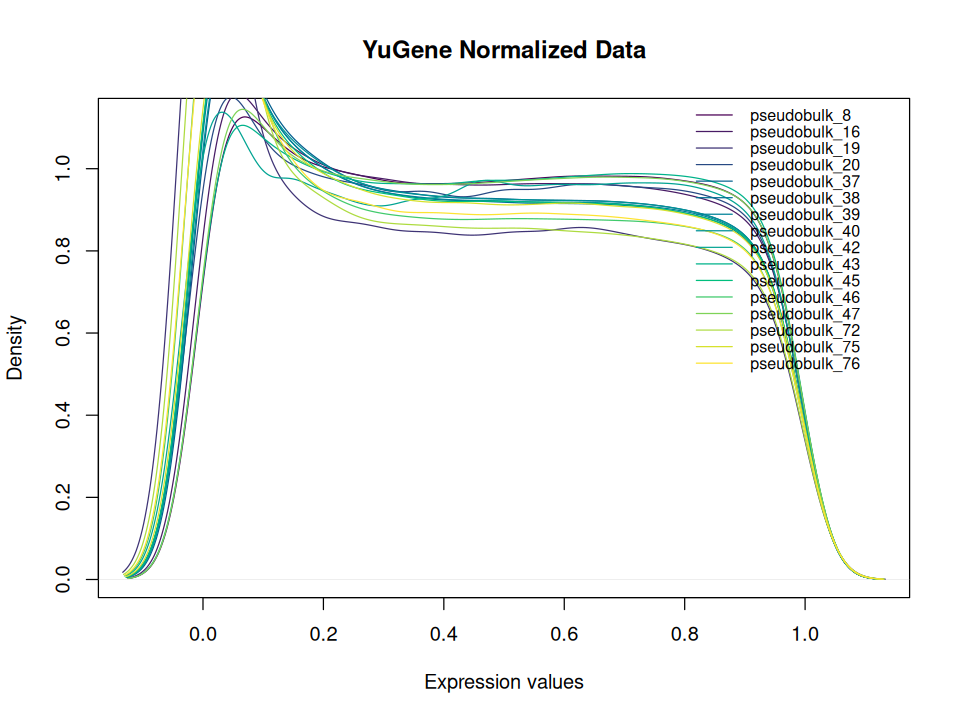

✓ Control samples found for label '1m'. Using control group median for subtraction.


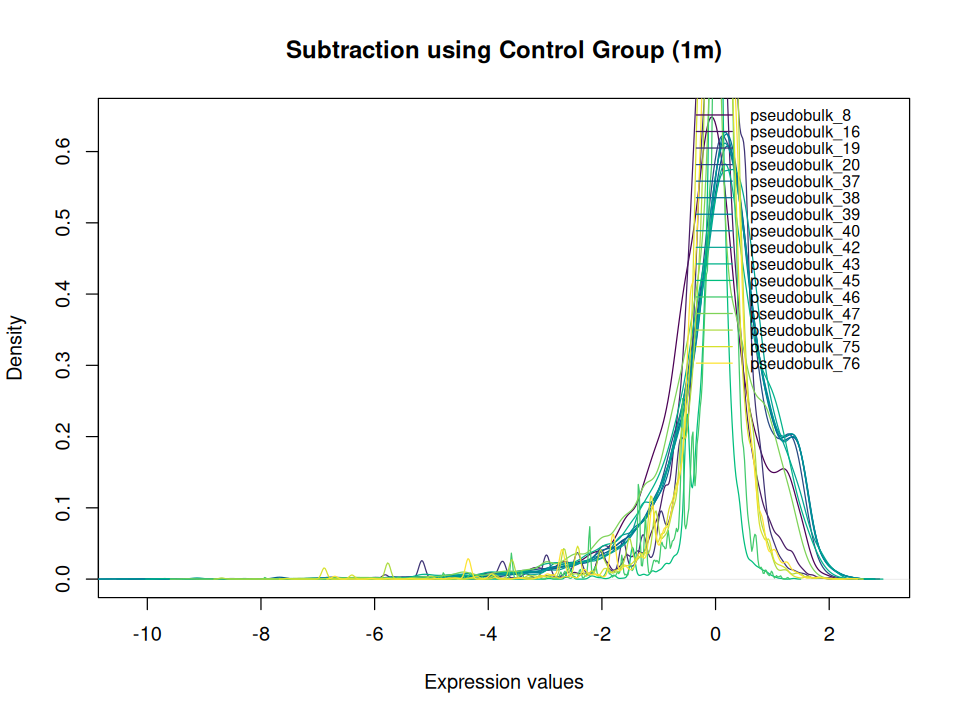


✓ Combined results: 69 samples from 3 groups

tAge Predictions:
                         sample_id cumulative_coverage n_cells age mouse.id
Tongue.pseudobulk_1   pseudobulk_1            10023560     457 24m  24-M-60
Tongue.pseudobulk_2   pseudobulk_2            10018216     437 24m  24-M-60
Tongue.pseudobulk_3   pseudobulk_3            10014731     429 24m  24-M-60
Tongue.pseudobulk_10 pseudobulk_10            10008561     593 18m  18-M-52
Tongue.pseudobulk_11 pseudobulk_11            10026991     639 18m  18-M-52
Tongue.pseudobulk_12 pseudobulk_12            10037656     613 18m  18-M-52
                     tissue scaled_diff_EN_tAge yugene_diff_EN_tAge
Tongue.pseudobulk_1  Tongue            8.036580            8.094695
Tongue.pseudobulk_2  Tongue            7.798035            7.723126
Tongue.pseudobulk_3  Tongue            7.411046            7.478156
Tongue.pseudobulk_10 Tongue            3.819249            5.831976
Tongue.pseudobulk_11 Tongue            4.065234            6.09

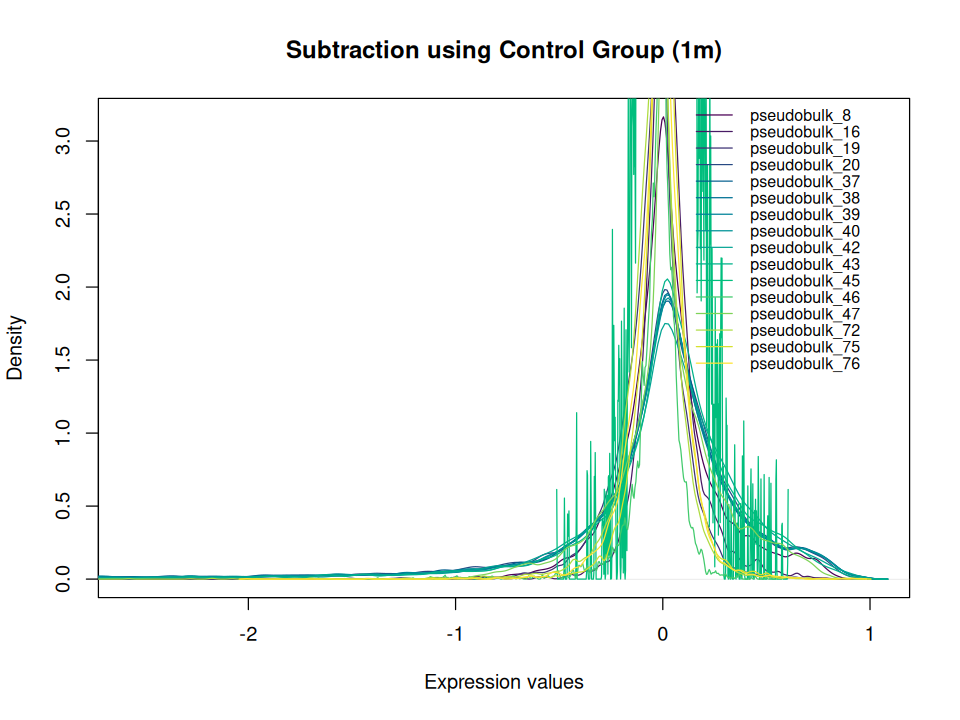

In [ ]:
# Set up model paths
model_paths <- list(
  scaled_diff = "path/to/EN_scaleddiff.pkl",
  yugene_diff = "path/to/EN_yugenediff.pkl"
)
# Set Python environment
Sys.setenv(RETICULATE_PYTHON = "./.venv/bin/python")

results <- tAge_by_group(
  eset = eset_clean,
  split_by = "tissue",
  model_paths = model_paths,
  species = "mouse",
  mode = "EN",
  control_group_column = "age",
  control_group_label = "1m",
  verbose = TRUE
)

cat("\ntAge Predictions:\n")
print(head(results))

## 10. Visualize Results

Correlation with chronological age:
   Tongue - scaled: 0.888 | yugene: 0.817 (n= 38 )
   Kidney - scaled: 0.942 | yugene: 0.893 (n= 15 )
   Liver - scaled: 0.92 | yugene: 0.919 (n= 16 )

Overall:
  scaled: 0.788 
  yugene: 0.793 


`geom_smooth()` using formula = 'y ~ x'


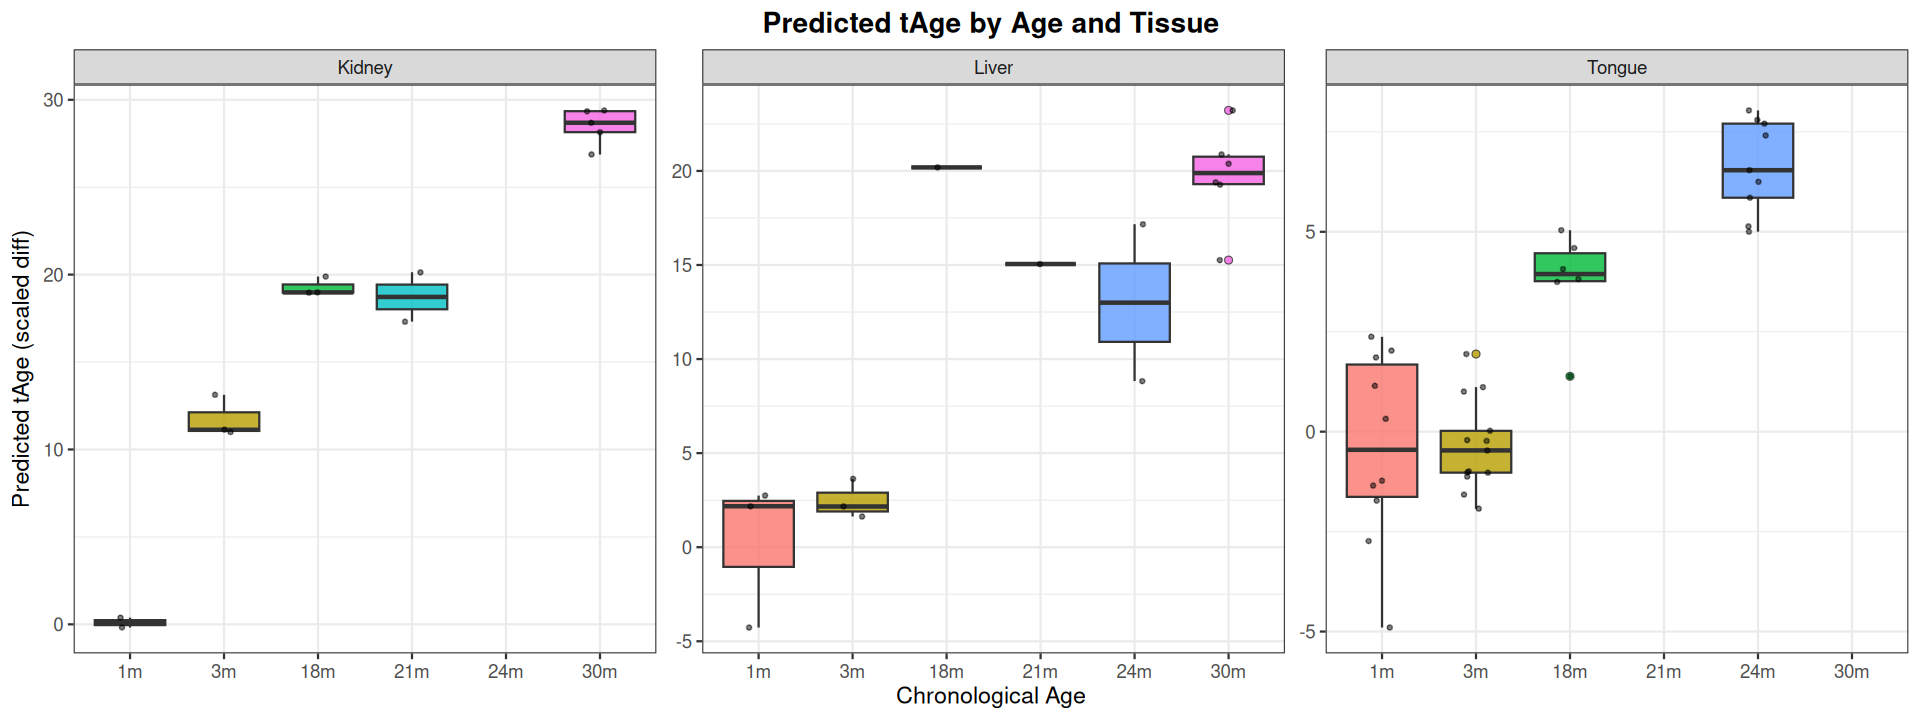

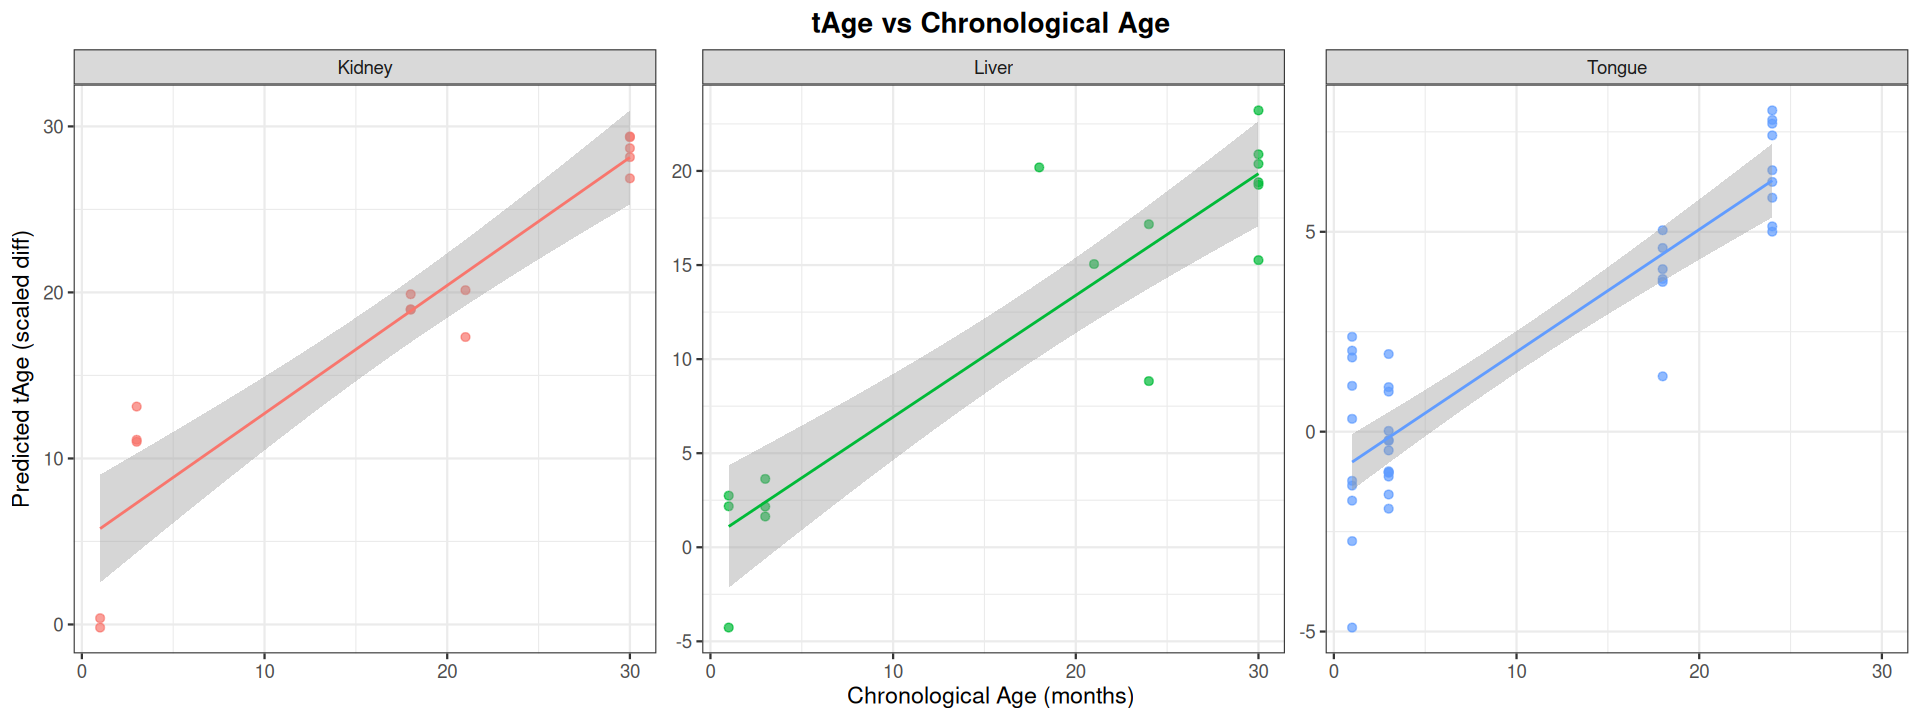

In [27]:
options(repr.plot.width = 16, repr.plot.height = 6)

# Chronological age as number
results$age_numeric <- as.numeric(gsub("m", "", results$age))

# Correlation with chronological age for each tissue
cat("Correlation with chronological age:\n")
for (tissue in unique(results$tissue)) {
  sub <- results[results$tissue == tissue, ]
  cor_s <- cor(sub$age_numeric, sub$scaled_diff_EN_tAge, use = "complete.obs")
  cor_y <- cor(sub$age_numeric, sub$yugene_diff_EN_tAge, use = "complete.obs")
  cat("  ", tissue, "- scaled:", round(cor_s, 3), "| yugene:", round(cor_y, 3),
      "(n=", nrow(sub), ")\n")
}

# Common correlation
cat("\nOverall:\n")
cat("  scaled:", round(cor(results$age_numeric, results$scaled_diff_EN_tAge, use="complete.obs"), 3), "\n")
cat("  yugene:", round(cor(results$age_numeric, results$yugene_diff_EN_tAge, use="complete.obs"), 3), "\n")

# Boxplot
library(ggplot2)

p <- ggplot(results, aes(x = factor(age, levels = c("1m","3m","18m","21m","24m","30m")),
                          y = scaled_diff_EN_tAge, fill = age)) +
  geom_boxplot(outlier.shape = 21, alpha = 0.8) +
  geom_jitter(width = 0.15, size = 1, alpha = 0.5) +
  facet_wrap(~tissue, scales = "free_y") +
  labs(title = "Predicted tAge by Age and Tissue",
       x = "Chronological Age",
       y = "Predicted tAge (scaled diff)") +
  theme_bw(base_size = 14) +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5, face = "bold"))

print(p)

# Scatter: tAge vs chronological age
p2 <- ggplot(results, aes(x = age_numeric, y = scaled_diff_EN_tAge, color = tissue)) +
  geom_point(size = 2, alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, linewidth = 0.8) +
  facet_wrap(~tissue, scales = "free_y") +
  labs(title = "tAge vs Chronological Age",
       x = "Chronological Age (months)",
       y = "Predicted tAge (scaled diff)") +
  theme_bw(base_size = 14) +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5, face = "bold"))

print(p2)

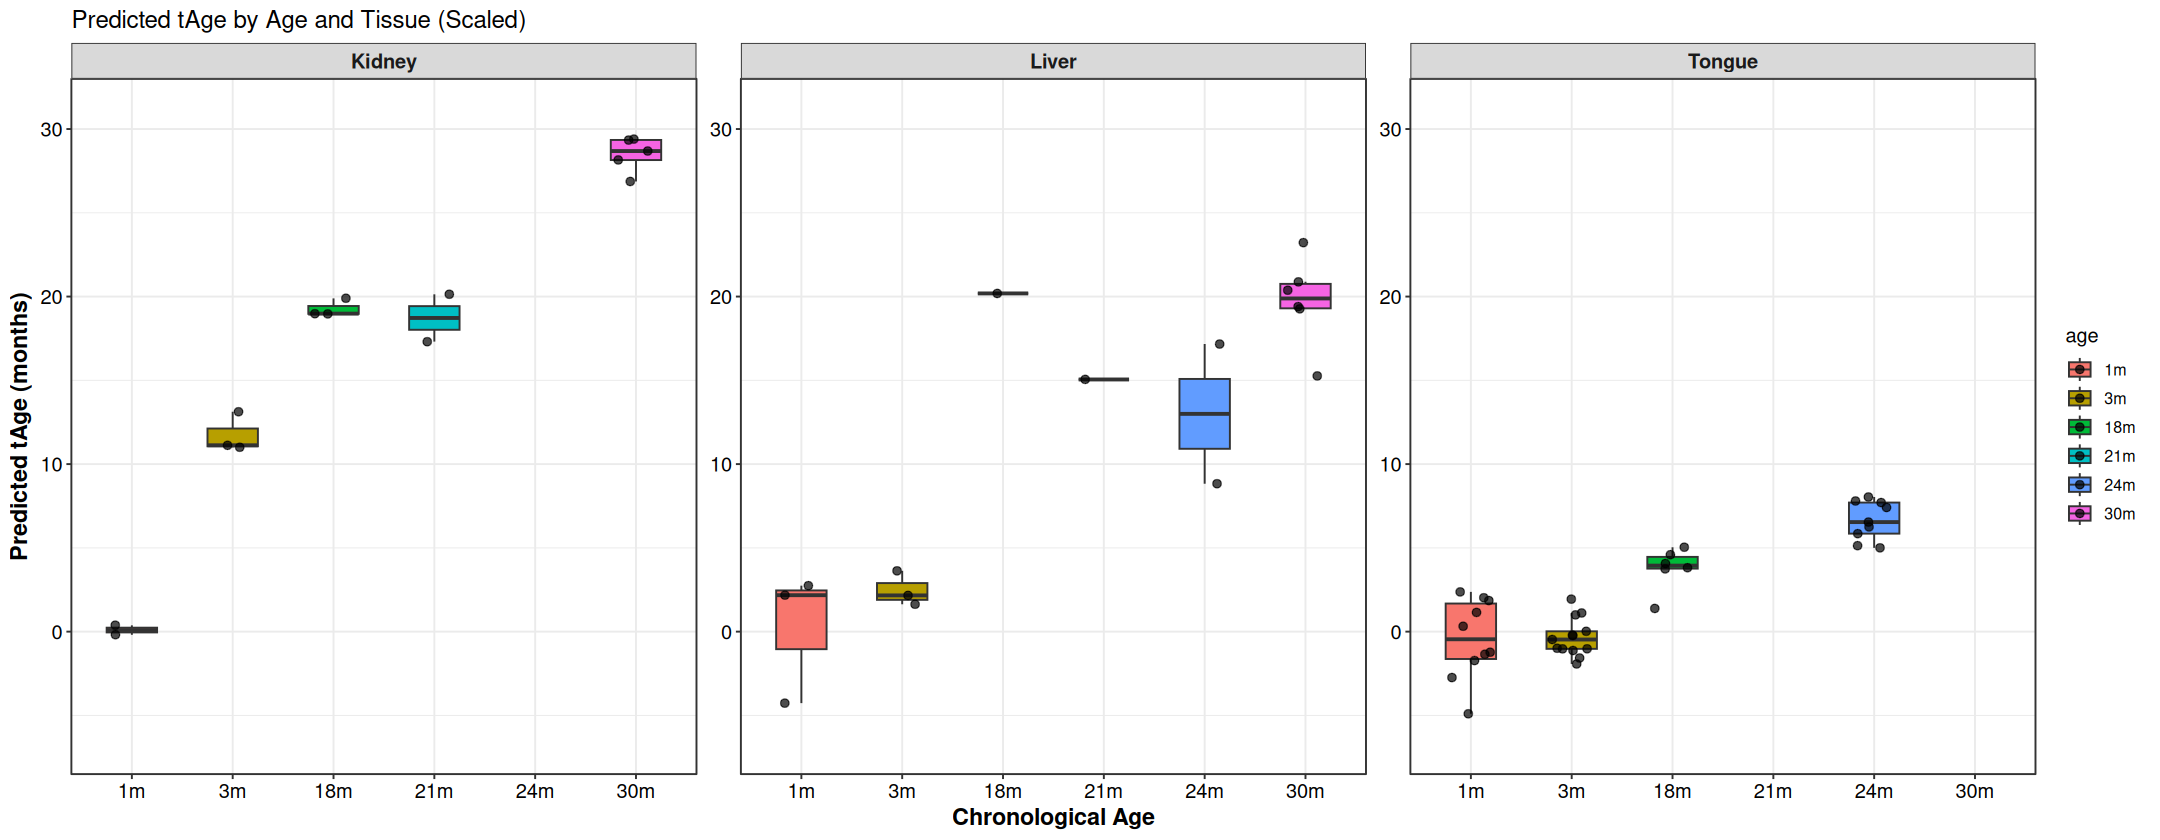

In [28]:
options(repr.plot.width = 18, repr.plot.height = 7)

p <- tage_boxplot(
  results,
  x_var = "age",
  y_var = "scaled_diff_EN_tAge",
  subgroup_var = "tissue",
  stat_method = "wilcox.test",
  theme_type = "bw",
  title = "Predicted tAge by Age and Tissue (Scaled)",
  xlab = "Chronological Age",
  ylab = "Predicted tAge (months)",
  p_label = "p.format",
  p_threshold = 0.05,
  min_group_n = 3,
  facet_scales = "free_y",
  x_order = c("1m", "3m", "18m", "21m", "24m", "30m"),
  width = 18,
  height = 7
)
print(p)